<center>Final Project: Data Science Pipeline Tutorial<\center>
<center>Alcohol Consumption Amongst Students<\center>
<center>Benjamin Yi, Arno Babcock, and Petr Tsypnyatov<\center>

For our final project, we decided to focus on data containing key information on student alcohol consumption, which we found on data.world. In this tutorial, we will be showing you the various steps of the Data Science Pipeline, and how you can analyze and use whatever data you might be interested in. These steps can be broken down into the following:
Data collection/curation + parsing (if necessary),
Data management/representation,
Exploratory data analysis,
Hypothesis testing and machine learning, and
Communication of insights attained.
<br>
There are a few things that we will need to do to get set up. <br>
1. You will need an IDE to be able to run and test your code. We will be using Jupyter Notebook for this project, and recommend you do the same as it also functions as a presentation tool.<br>
2. Once you have an IDE installed, you can create a new file and begin writing your code.<br>
3. For this particular project, we are going to use a few Python libraries, which we will have listed here.<br>
4. Once you have all this set up, we can begin with the first step: collecting and parsing the data.<br>

# Data collection/curation + parsing (if necessary)

The first step of the Data Science Pipeline is finding the data you want to analyze. In our case, we want to take a look at the statistics for student alcohol consumption, and we are given a dataset as a .csv file. There are many ways for you to collect, or "scrape" your data, it can be on a website, in a table, or as an excel file. Since our data is in the form of a .csv file, we will use the pandas library to read it. We can use the read_csv() method from the pandas library to create a DataFrame object from a .csv file. A dataframe is a 2-dimensional labeled structure with columns that can have different types, which is perfect for what we need. We create the DataFrame, and assign it to a variable table, and then display table.

Note: What goes in parentheses is actually the path to the file that we want to read data from. Since we have the .csv file in the same folder as this project, we can just write the filename, otherwise you would need to add the entire file path before the name of the file.

In [2]:
import pandas as pd

table = pd.read_csv("student-mat.csv")
table

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


Now that we have the data as a DataFrame object, we can begin the next step which is managing and representing our data.

# Data management/representation


  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
    school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  \
0       GP

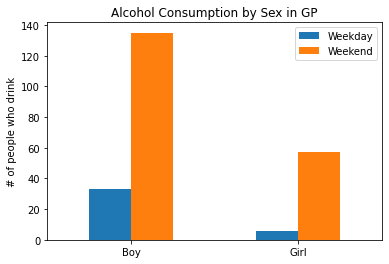

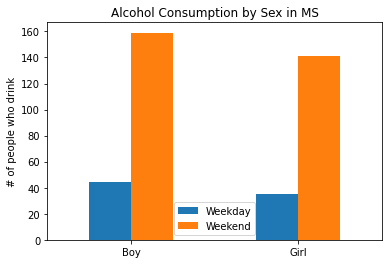

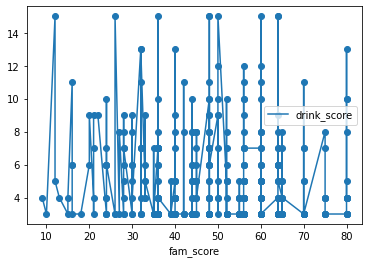

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('student-mat.csv')
print(data.head());

for t in data.groupby('school'):
    if t[0] == 'GP':
        Gp_tbl = t[1]
    else:
        MS_tbl = t[1]

print(Gp_tbl)

d_alcB= 0
w_alcB = 0

d_alcF = 0
w_alcF = 0


cur_D = 0
cur_W = 0;



for t in Gp_tbl.groupby("sex"):
    for index, row in t[1].iterrows():
        if row['Walc'] >= 3:
            cur_W+=1
        if row['Dalc'] >= 3:
            cur_D+=1

    if t[0] == "F":
        w_alcF = cur_W
        d_alcF = cur_D
    else:
        w_alcB = cur_W
        d_alcB = cur_D


d_alc = [d_alcB, d_alcF]
w_alc = [w_alcB, w_alcF]
index = ['Boy','Girl']

df = pd.DataFrame({'Weekday': d_alc,'Weekend': w_alc}, index=index)
ax = df.plot.bar(rot=0)
plt.ylabel("# of people who drink")
plt.title("Alcohol Consumption by Sex in GP")
plt.show()

for t in MS_tbl.groupby("sex"):
    for index, row in t[1].iterrows():
        if row['Walc'] >= 3:
            cur_W += 1
        if row['Dalc'] >= 3:
            cur_D += 1

    if t[0] == "F":
        w_alcF = cur_W
        d_alcF = cur_D
    else:
        w_alcB = cur_W
        d_alcB = cur_D

d_alc = [d_alcB, d_alcF]
w_alc = [w_alcB, w_alcF]
index = ['Boy', 'Girl']

df = pd.DataFrame({'Weekday': d_alc, 'Weekend': w_alc}, index=index)
ax = df.plot.bar(rot=0)
plt.ylabel("# of people who drink")
plt.title("Alcohol Consumption by Sex in MS")
plt.show()

# lets represent the statistics in a different way

data['fam_score'] = 0
data['drink_score'] = 0
score = 0

for index, row in data.iterrows():
    if row['Pstatus'] == 'A':
        score += 1
    else:
        score +=5

    score += row['Medu']
    score += row['Fedu']

    if row['Mjob'] == 'at_home' or row['Fjob'] == 'athome':
        score += 0
    elif row['Mjob'] == 'healthcare' or row['Fjob'] == 'healthcare':
        score +=5
    else:
        score+=3

    data.at[index,'fam_score'] = score * row['famrel']
    data.at[index,'drink_score'] = row['Dalc'] * 2 + row['Walc']

    score = 0;


data = data.sort_values(by='fam_score')


data.plot.line(x='fam_score', y='drink_score')
plt.scatter(data['fam_score'],data['drink_score'])

plt.show()

# Exploratory data analysis
# Hypothesis testing and machine learning
# Communication of insights attained